# 03b — Cluster Verification

Verify that clusters are stable and reflect real patient variation, not preprocessing artefacts.  
All checks use **train data only**.

In [1]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = '../data/processed'
MODELS    = '../models'
PLOTS     = '../results/plots'
print('Ready.')

Ready.


## Load Data

In [2]:
train_scaled   = pd.read_csv(f'{PROCESSED}/train_wide_scaled.csv')
train_unscaled = pd.read_csv(f'{PROCESSED}/train_wide_unscaled.csv')
train_clusters = pd.read_csv(f'{PROCESSED}/train_clusters.csv')

pca    = joblib.load(f'{MODELS}/pca.pkl')
kmeans = joblib.load(f'{MODELS}/kmeans.pkl')
best_k = kmeans.n_clusters

EXCLUDE = ['document_id','age','gender']
feat_cols = [c for c in train_scaled.columns
             if c not in EXCLUDE and not c.endswith('_missing')]

X_train = train_scaled[feat_cols].values
X_pca   = pca.transform(X_train)
ref_labels = train_clusters.set_index('document_id')['cluster_id'].reindex(train_scaled['document_id']).values

print(f'k={best_k}, train patients={len(train_scaled):,}')

k=5, train patients=79,993


## Check 1 — Bootstrap Stability (ARI)

Resample train with replacement 10 times, refit K-Means on each bootstrap sample,  
then assign clusters to the **original** train patients and compute Adjusted Rand Index vs. the reference solution.  
Mean ARI > 0.6 indicates reasonable stability.

In [3]:
N_BOOT = 10
ari_scores = []
n = len(X_pca)

for seed in range(N_BOOT):
    rng = np.random.default_rng(seed)
    boot_idx = rng.integers(0, n, size=n)
    X_boot   = X_pca[boot_idx]

    km_boot = KMeans(n_clusters=best_k, random_state=seed, n_init=10)
    km_boot.fit(X_boot)

    boot_labels = km_boot.predict(X_pca)  # assign original patients
    ari = adjusted_rand_score(ref_labels, boot_labels)
    ari_scores.append(ari)
    print(f'Bootstrap {seed:02d}: ARI = {ari:.4f}')

print(f'\nMean ARI : {np.mean(ari_scores):.4f}')
print(f'Std  ARI : {np.std(ari_scores):.4f}')
if np.mean(ari_scores) > 0.6:
    print('✅ Cluster solution is stable (mean ARI > 0.6).')
else:
    print('⚠️  Cluster solution may be unstable (mean ARI ≤ 0.6).')

Bootstrap 00: ARI = 0.4477
Bootstrap 01: ARI = 0.4517
Bootstrap 02: ARI = 0.4313
Bootstrap 03: ARI = 0.4679
Bootstrap 04: ARI = 0.9407
Bootstrap 05: ARI = 0.4868
Bootstrap 06: ARI = 0.9018
Bootstrap 07: ARI = 0.7773
Bootstrap 08: ARI = 0.7456
Bootstrap 09: ARI = 0.4688

Mean ARI : 0.6120
Std  ARI : 0.1948
✅ Cluster solution is stable (mean ARI > 0.6).


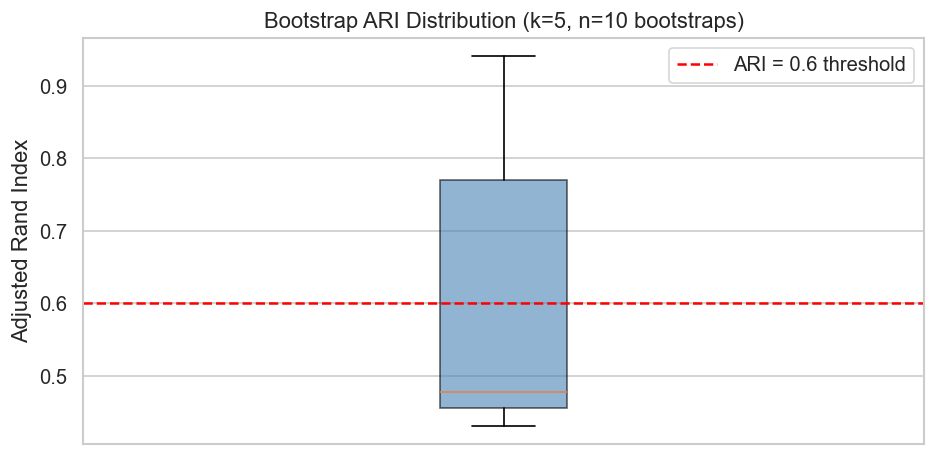

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(ari_scores, vert=True, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.axhline(0.6, color='red', linestyle='--', label='ARI = 0.6 threshold')
ax.set_title(f'Bootstrap ARI Distribution (k={best_k}, n=10 bootstraps)')
ax.set_ylabel('Adjusted Rand Index')
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/bootstrap_ari.png', bbox_inches='tight')
plt.show()

## Check 2 — Random Seed Sensitivity

In [5]:
SEEDS = [0, 1, 7, 13, 99]
seed_aris = []

for s in SEEDS:
    km_s = KMeans(n_clusters=best_k, random_state=s, n_init=20)
    labels_s = km_s.fit_predict(X_pca)
    ari = adjusted_rand_score(ref_labels, labels_s)
    seed_aris.append(ari)
    print(f'seed={s:3d}: ARI = {ari:.4f}')

print(f'\nSeed ARI range: {min(seed_aris):.4f} – {max(seed_aris):.4f}')
if max(seed_aris) - min(seed_aris) < 0.1:
    print('✅ Low seed sensitivity — solution is robust.')
else:
    print('⚠️  High seed sensitivity — solution may not be robust.')

seed=  0: ARI = 0.7683
seed=  1: ARI = 0.4751
seed=  7: ARI = 0.4737
seed= 13: ARI = 0.7929
seed= 99: ARI = 0.4568

Seed ARI range: 0.4568 – 0.7929
⚠️  High seed sensitivity — solution may not be robust.


## Check 3 — Missingness-Driven Cluster Check

Uses **unscaled** (pre-imputation NaN pattern) train data.

Cluster 0: 0.00%  (Δ +0.00pp)
Cluster 1: 0.00%  (Δ +0.00pp)
Cluster 2: 0.00%  (Δ +0.00pp)
Cluster 3: 0.00%  (Δ +0.00pp)
Cluster 4: 0.00%  (Δ +0.00pp)


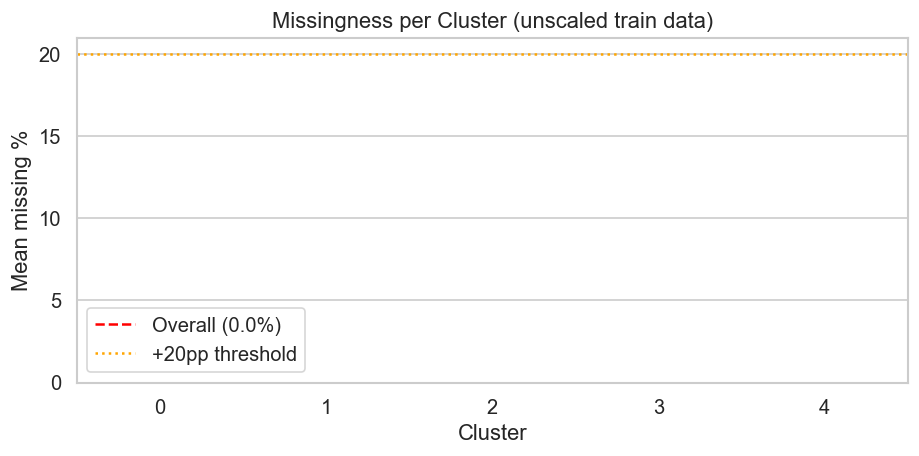

In [6]:
feat_cols_us = [c for c in train_unscaled.columns
                if c not in ['document_id','age','gender'] and not c.endswith('_missing')]

train_unscaled['cluster_id'] = ref_labels
overall_miss = train_unscaled[feat_cols_us].isnull().mean(axis=1).mean() * 100

cluster_miss = {}
for c in sorted(train_unscaled['cluster_id'].unique()):
    grp  = train_unscaled[train_unscaled['cluster_id']==c]
    miss = grp[feat_cols_us].isnull().mean(axis=1).mean() * 100
    cluster_miss[c] = miss
    diff = miss - overall_miss
    flag = '  ⚠️  WARNING: possibly missingness-driven!' if diff > 20 else ''
    print(f'Cluster {c}: {miss:.2f}%  (Δ {diff:+.2f}pp){flag}')

miss_df = pd.DataFrame({'cluster': list(cluster_miss.keys()),
                         'missing_pct': list(cluster_miss.values())})
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x='cluster', y='missing_pct', data=miss_df, palette='Blues_r', ax=ax)
ax.axhline(overall_miss, color='red', linestyle='--', label=f'Overall ({overall_miss:.1f}%)')
ax.axhline(overall_miss+20, color='orange', linestyle=':', label='+20pp threshold')
ax.set_title('Missingness per Cluster (unscaled train data)')
ax.set_xlabel('Cluster'); ax.set_ylabel('Mean missing %')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/verified_cluster_missingness.png', bbox_inches='tight')
plt.show()

## Check 4 — Feature Importance in Clustering

Fit a shallow Decision Tree to predict `cluster_id` from unscaled features.  
Top features reveal whether clusters are driven by lab values (good) or demographics alone.

Top 10 cluster-driving features:
Absolute Lymphocyte Count    0.461994
TOTAL CHOLESTEROL            0.219725
Hemoglobin                   0.146041
Non HDL Cholesterol          0.090668
PCT                          0.026733
Creatinine                   0.019068
Total WBC Count              0.015498
TC/ HDL CHOLESTEROL RATIO    0.010659
Absolute Eosinophil Count    0.008786
PCV                          0.000662


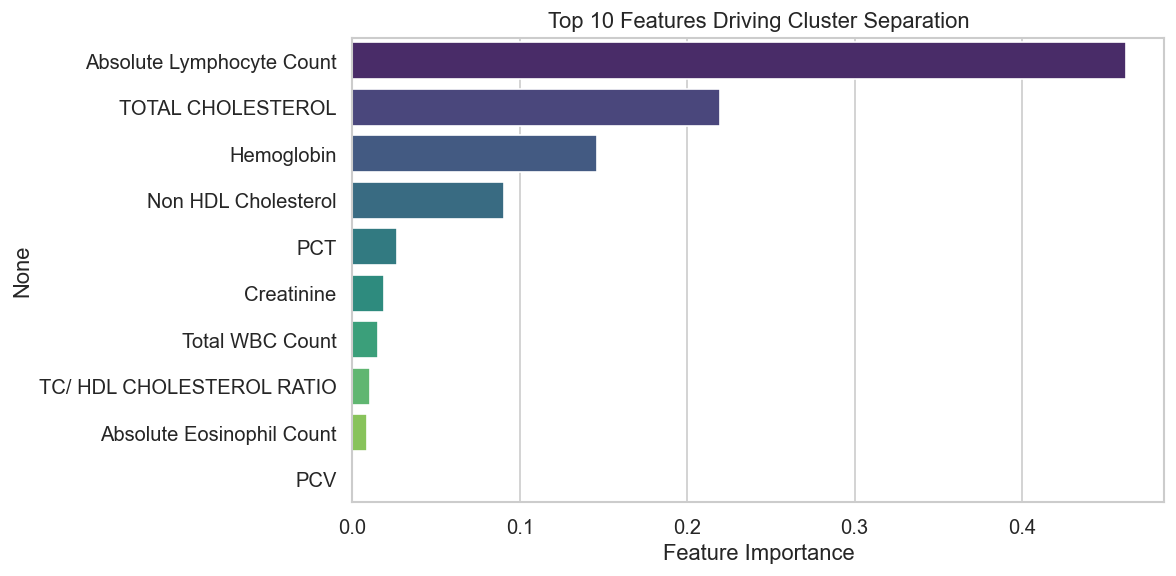

In [7]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
X_dt = train_unscaled[feat_cols_us].fillna(train_unscaled[feat_cols_us].median())
dt.fit(X_dt, ref_labels)

fi = pd.Series(dt.feature_importances_, index=feat_cols_us)\
       .sort_values(ascending=False)

print('Top 10 cluster-driving features:')
print(fi.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=fi.head(10).values, y=fi.head(10).index, palette='viridis', ax=ax)
ax.set_title('Top 10 Features Driving Cluster Separation')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig(f'{PLOTS}/cluster_feature_importance.png', bbox_inches='tight')
plt.show()

## Check 5 — Summary

In [8]:
any_miss_warn = any(v - overall_miss > 20 for v in cluster_miss.values())
top3_feats = fi.head(3).index.tolist()

print('='*55)
print('  CLUSTER VERIFICATION SUMMARY')
print('='*55)
print(f'  k (clusters)         : {best_k}')
print(f'  Bootstrap mean ARI   : {np.mean(ari_scores):.4f} ± {np.std(ari_scores):.4f}')
print(f'  Seed ARI range       : {min(seed_aris):.4f} – {max(seed_aris):.4f}')
print(f'  Missingness warning  : {"YES ⚠️" if any_miss_warn else "No ✅"}')
print(f'  Top cluster features : {top3_feats}')
print('='*55)
print('This summary will be quoted in the paper methods section.')

  CLUSTER VERIFICATION SUMMARY
  k (clusters)         : 5
  Bootstrap mean ARI   : 0.6120 ± 0.1948
  Seed ARI range       : 0.4568 – 0.7929
  Missingness warning  : No ✅
  Top cluster features : ['Absolute Lymphocyte Count', 'TOTAL CHOLESTEROL', 'Hemoglobin']
This summary will be quoted in the paper methods section.
